In [1]:
import dask
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches
import numpy as np
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmcrameri as cm
import os
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
import warnings
from cmcrameri import cm
import cfgrib
import glob

import babet as bb
import atmicp

warnings.filterwarnings("ignore", category=FutureWarning)
dask.config.set(**{'array.slicing.split_large_chunks': True})

In [2]:
atmicp.style.set_style()

# climate scenario colours from the shared style
CLIM = {'pi': atmicp.style.climate_color('1870'),        # blue
        'curr': atmicp.style.climate_color('present'),   # grey
        'incr': atmicp.style.climate_color('future1')}   # orange

LABEL = {'pi': 'pre-industrial', 'curr': 'current', 'incr': 'increased'}

# one linestyle per perturbation, so climate stays the only thing colour encodes
LS = {'iterated': '-.',
      'iterated_short': ':',
      'tq': '--',
      'ocean': '-',
      'none': '-'}

PERT_LABEL = {'iterated': 'iterated',
              'iterated_short': 'iterated, short',
              'tq': 'delta t+q',
              'ocean': 'ocean only',
              'none': 'unperturbed'}

In [3]:
## and one for the z indices

def extract_z_indices(ds):
    
    # get three indices of geopotential height - mean, max & L-O blocking
    z_max = ds.z.sel(latitude=slice(60,35),longitude=slice(230,250)).max(['latitude','longitude'])
    z_block = (ds.z.sel(latitude=40,longitude=slice(230,250)) - ds.z.sel(latitude=60,longitude=slice(230,250))).mean('longitude')
    z_mean = ds.z.sel(latitude=slice(60,35),longitude=slice(230,250)).weighted(np.cos(np.deg2rad(ds.latitude))).mean(['latitude','longitude'])
    
    return xr.merge([z_max.rename('z500_max'),z_mean.rename('z500_mean'),z_block.rename('z500_blo')])

# Import data

In [4]:
# tcc and swvl1 on top of the defaults, for the corner plot
ifs_sfc = atmicp.Data.get_ifs_data(levtype='sfc', res='US025',
                                   variables=['t2m', 'msl', 'tcwv', 'tcc', 'swvl1'])

Loading 3 file(s) for b2vj (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/cf


Loading 3 file(s) for b2vj (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/pf
Loading 3 file(s) for b2vr (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/cf
Loading 3 file(s) for b2vr (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/pf
Loading 3 file(s) for b2vl (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/cf
Loading 3 file(s) for b2vl (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/pf
Loading 3 file(s) for b2vo (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/cf
Loading 3 file(s) for b2vo (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/pf
Loading 3 file(s) for b2ut (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/curr/US025/sfc/cf
Loading 3 file(s) for b2ut (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/curr/US025/sfc/pf
Loading 3 file(s) for b2vk (cf) from /gf5/

In [5]:
ifs_pl = atmicp.Data.get_ifs_data(levtype='pl', res='GLO100')

Loading 3 file(s) for b2vj (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/GLO100/pl/cf


Loading 3 file(s) for b2vj (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/GLO100/pl/pf
Loading 3 file(s) for b2vr (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/GLO100/pl/cf
Loading 3 file(s) for b2vr (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/GLO100/pl/pf
Loading 3 file(s) for b2vl (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/GLO100/pl/cf
Loading 3 file(s) for b2vl (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/GLO100/pl/pf
Loading 3 file(s) for b2vo (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/GLO100/pl/cf
Loading 3 file(s) for b2vo (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/GLO100/pl/pf
Loading 3 file(s) for b2ut (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/curr/GLO100/pl/cf
Loading 3 file(s) for b2ut (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/curr/GLO100/pl/pf
Loading 3 file(s) for b2vk (cf) from /gf5/

/home/e/ermis/ATMICP/atmicp/data.py:255: UserWarning: b2vq: missing inidates ['b2vq_2021-06-22.nc', 'b2vq_2021-06-26.nc'] in /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/GLO100/pl/cf
  warnings.warn(
/home/e/ermis/ATMICP/atmicp/data.py:255: UserWarning: b2vq: missing inidates ['b2vq_2021-06-22.nc', 'b2vq_2021-06-26.nc'] in /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/GLO100/pl/pf
  warnings.warn(


Loading 3 file(s) for b2vm (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/GLO100/pl/pf
Loading 3 file(s) for b2vn (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/GLO100/pl/cf
Loading 3 file(s) for b2vn (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/GLO100/pl/pf


In [6]:
era5_sfc = xr.open_mfdataset(glob.glob('/network/group/aopp/archive02a/projects/predict/AWH009_LEACH_RELIABLE/COUNTERFACTUAL-FORECASTING/DATA/postproc/WWAmean/era5/sfc/*.nc'))
# convert variables to consistent units:
era5_sfc['tp'] *= 24 * 1000 # convert to mm day-1
era5_sfc['e'] *= 1 / 3600 # convert to m s-1
print('got ERA5')

got ERA5


In [7]:
era5_z500 = extract_z_indices(xr.open_mfdataset(glob.glob('/network/group/aopp/archive02a/projects/predict/AWH009_LEACH_RELIABLE/COUNTERFACTUAL-FORECASTING/DATA/era5/glo100/pl/*.nc'))).load()
print('got ERA5')

got ERA5


In [8]:
# q, u and v for IVT are in the rquv file; the dztw file next to it only has d, z, t and w
era5_glo_pl = xr.open_dataset('/network/group/aopp/archive02a/projects/predict/AWH009_LEACH_RELIABLE/COUNTERFACTUAL-FORECASTING/DATA/era5/glo250/pl/2021_MJJA_rquv.nc')
print('got ERA5')

got ERA5


# Process data

In [9]:
pnw = atmicp.Constants.pnw
box = dict(longitude=slice(pnw[0], pnw[1]), latitude=slice(pnw[3], pnw[2]))
ifs_pnw = (ifs_sfc.sel(time=slice('2021-06-26', '2021-07-01'), **box)
           .mean(['latitude', 'longitude']).compute())

# climate/perturbation combinations that never ran are NaN-filled by the concat
ifs_pnw = ifs_pnw.stack(z=['perturbation', 'climate', 'inidate', 'number']).dropna('z', how='all')

max_t2m_times = ifs_pnw.t2m.idxmax('time')
exp_max_df = ifs_pnw.sel(time=max_t2m_times).to_dataframe()

# Compare IVT locations in time

In [10]:
## integrate over the levels the IFS runs and ERA5 share, so the ERA5 point on the
## corner plot is computed the same way as the ensemble (the IFS runs also have
## 600, 400 and 300 hPa, the ERA5 files do not)
IVT_LEVELS = [1000, 925, 850, 700, 500, 250]
AR_LON = 220
AR_TIMES = pd.to_datetime(['2021-06-24', '2021-06-25'])

def get_IVT(ds, levels=IVT_LEVELS):
    """Vertically integrated vapour transport (kg m-1 s-1), 1000-250 hPa.

    Levels are sorted to increasing pressure and integrated in Pa, so the sign and
    units come out right whichever way round the file stores them (the IFS files
    run 1000 -> 200 hPa, the ERA5 ones 10 -> 1000 hPa).
    """
    ds = ds[['q', 'u', 'v']].sel(level=levels).sortby('level')
    ds = ds.assign_coords(level=ds.level * 100.)   # hPa -> Pa

    out = xr.Dataset()
    out['q_u'] = (ds.q * ds.u).integrate('level') / 9.80665
    out['q_v'] = (ds.q * ds.v).integrate('level') / 9.80665

    return out

In [12]:
# only the window the maps show is read: 0-90N, 120-300E
ivt_unperturbed = get_IVT(ifs_pl.sel(climate='curr', perturbation='none',
                         latitude=slice(90, 0), longitude=slice(120, 300)))
# magnitude per member first, then the ensemble mean
ivt_unperturbed['ivt'] = (ivt_unperturbed.q_u**2 + ivt_unperturbed.q_v**2)**(1/2)
ivt_unperturbed = ivt_unperturbed.mean('number').compute()

In [13]:
# only the window the maps show is read: 0-90N, 120-300E
ivt = get_IVT(ifs_pl.sel(perturbation='tq',
                         latitude=slice(90, 0), longitude=slice(120, 300)))
# magnitude per member first, then the ensemble mean
ivt['ivt'] = (ivt.q_u**2 + ivt.q_v**2)**(1/2)
ivt = ivt.mean('number').compute()

In [ ]:
IVT_EXTENT = [120, 300, 0, 90]
IVT_VMAX = 1000         # kg m-1 s-1
QUIVER_SCALE = 20000    # kg m-1 s-1 per panel width: the template's scale=200 in hPa units


def ivt_daily_maps(ivt,
                   inidate, 
                   climate_label, perturbation_label,
                   unperturbed=None,
                   ncol=3, stride=3, width=10.0):
    """IVT at every daily step of one initialisation, as a grid of maps.

    One panel per step from `inidate` on, `ncol` to a row, with one colourbar and
    one reference arrow for the whole figure.
    """
    inidate = np.datetime64(inidate, 'ns')
    steps = ivt.time.values[ivt.time.values >= inidate]
    nrow = int(np.ceil(len(steps) / ncol))

    lon0, lon1, lat0, lat1 = IVT_EXTENT
    panel_w = width / ncol
    panel_h = panel_w * (lat1 - lat0) / (lon1 - lon0)
    height = nrow * (panel_h + 0.25) + 1.0

    fig = plt.figure(figsize=(width, height))
    gs = fig.add_gridspec(nrow, ncol, left=0.01, right=0.99, top=1 - 0.6 / height,
                          bottom=0.75 / height, wspace=0.04, hspace=0.18)
    fs = atmicp.style.scaled(atmicp.style.FS_SMALL, fig)

    proj = ccrs.PlateCarree(central_longitude=180)
    for i, step in enumerate(steps):
        ax = fig.add_subplot(gs[i // ncol, i % ncol], projection=proj)
        da = ivt.sel(inidate=inidate, time=step) - unperturbed.sel(inidate=inidate, time=step) if unperturbed is not None else ivt.sel(inidate=inidate, time=step)

        if unperturbed is not None:
            da_unpert = unperturbed.sel(inidate=inidate, time=step)
            unperturbed_contour = ax.contour(da.longitude, da.latitude, da_unpert.ivt, levels=[300, 500, 700, 900], 
                                             colors='white', linewidths=0.5, transform=ccrs.PlateCarree(), zorder=11)
            
            mesh = ax.pcolormesh(da.longitude, da.latitude, da.ivt, cmap=cm.broc_r,
                                vmin=-IVT_VMAX/5, vmax=IVT_VMAX/5, transform=ccrs.PlateCarree())
        else:
            mesh = ax.pcolormesh(da.longitude, da.latitude, da.ivt, cmap='Blues',
                                 vmin=0, vmax=IVT_VMAX, transform=ccrs.PlateCarree())
        
        # offset by half a stride, so no arrow sits on the pole where its direction is undefined
        sub = da.isel(latitude=slice(stride // 2, None, stride), longitude=slice(stride // 2, None, stride))
        arrows = ax.quiver(sub.longitude.values, sub.latitude.values, sub.q_u.values, sub.q_v.values,
                           scale=QUIVER_SCALE, width=0.0015, color=atmicp.style.INK,
                           transform=ccrs.PlateCarree())

        ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.4,
                       edgecolor=atmicp.style.MUTED)
        ax.plot([AR_LON, AR_LON], [30, 70], color=atmicp.style.INK, linestyle='--',
                linewidth=0.8, transform=ccrs.PlateCarree())
        ax.set_extent(IVT_EXTENT, crs=ccrs.PlateCarree())

        lead = int((step - inidate) / np.timedelta64(1, 'D'))
        ax.set_title(f'{np.datetime_as_string(step, unit="D")}  (day {lead})', fontsize=fs)

    cax = fig.add_axes([0.25, 0.30 / height, 0.4, 0.10 / height])
    cbar = fig.colorbar(mesh, cax=cax, orientation='horizontal', extend='max')
    cbar.set_label('Ensemble-mean IVT (kg m$^{-1}$ s$^{-1}$)', fontsize=fs)
    cbar.ax.tick_params(labelsize=atmicp.style.scaled(atmicp.style.FS_XSMALL, fig))
    ax.quiverkey(arrows, X=0.78, Y=0.35 / height, U=1000, coordinates='figure',
                 label='1000 kg m$^{-1}$ s$^{-1}$', labelpos='E',
                 fontproperties={'size': fs})

    fig.suptitle(f'IVT, {climate_label}, {perturbation_label} - unperturbed, ' +
                 f'initialised {np.datetime_as_string(inidate, unit="D")}',
                 fontsize=atmicp.style.scaled(atmicp.style.FS_TITLE, fig),
                 y=1 - 0.08 / height, va='top')

    atmicp.style.save(fig, f'09_ivt_daily_{climate_label}-{perturbation_label}_{pd.Timestamp(inidate):%Y%m%d}')
    plt.show()

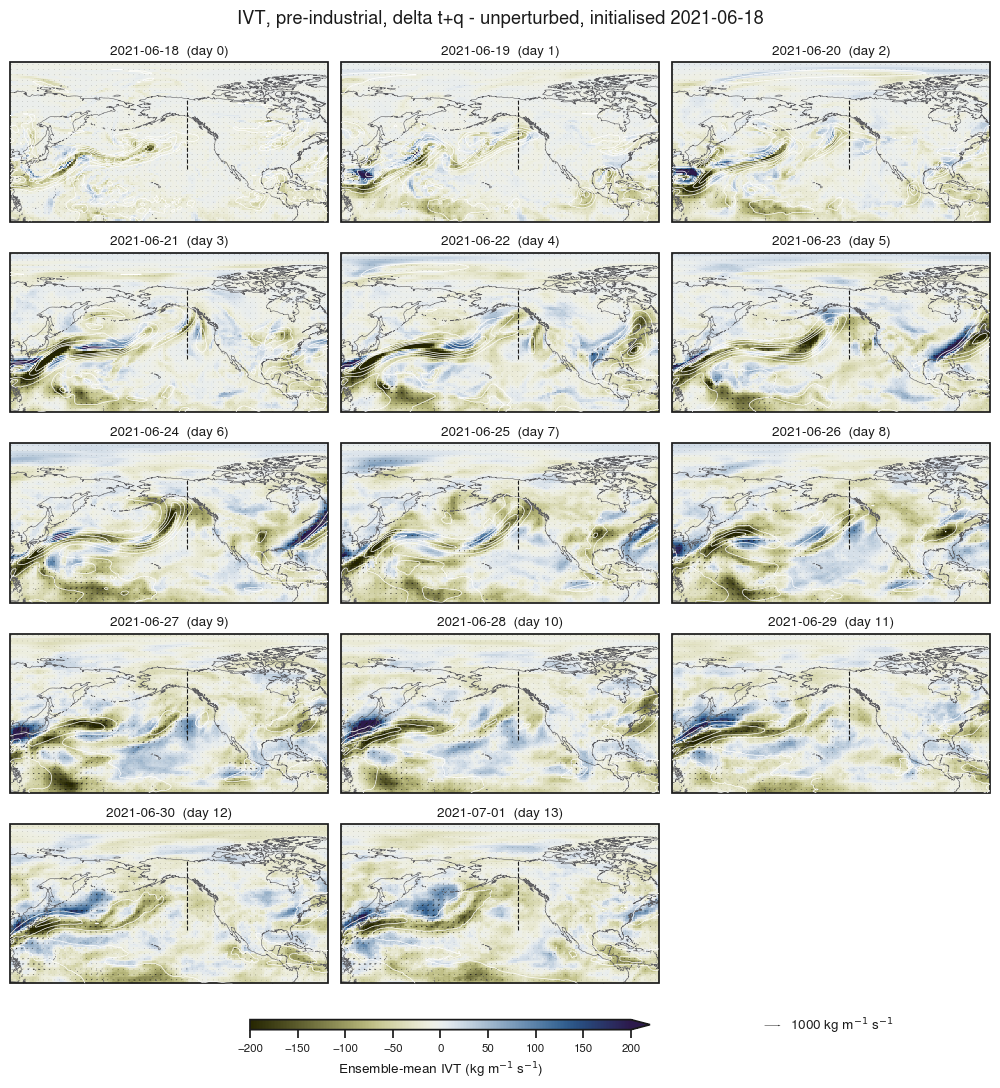

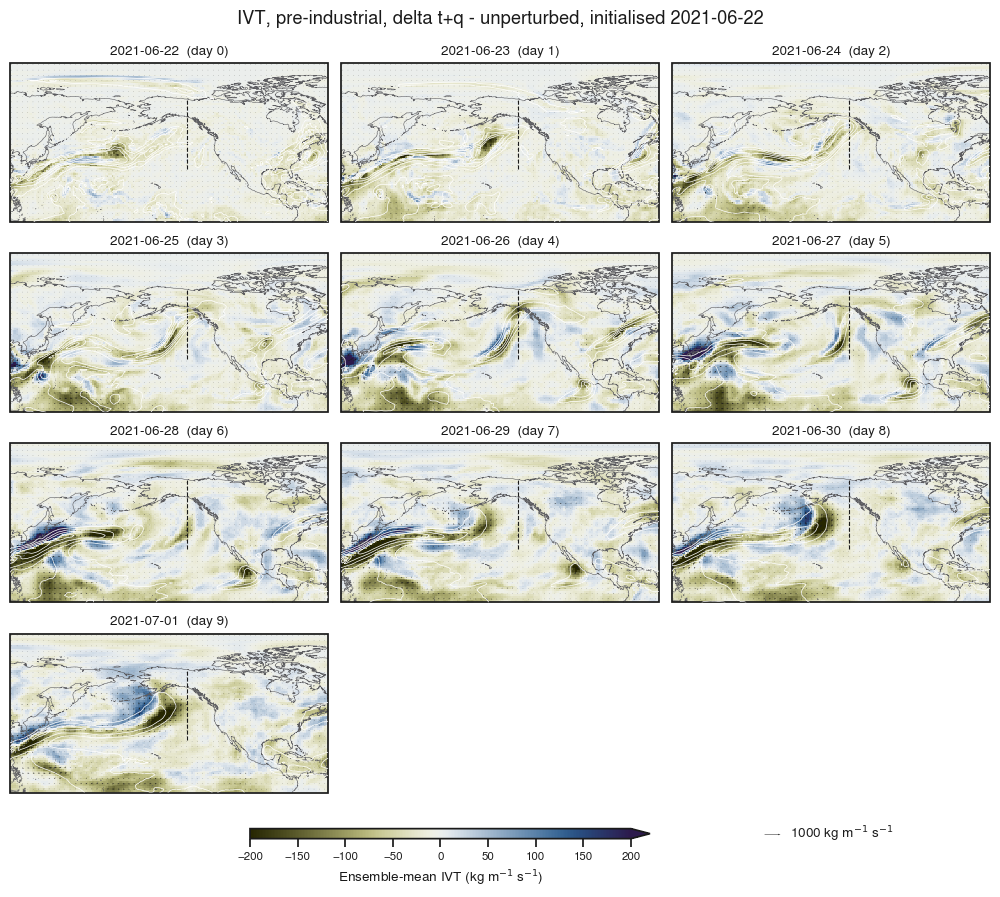

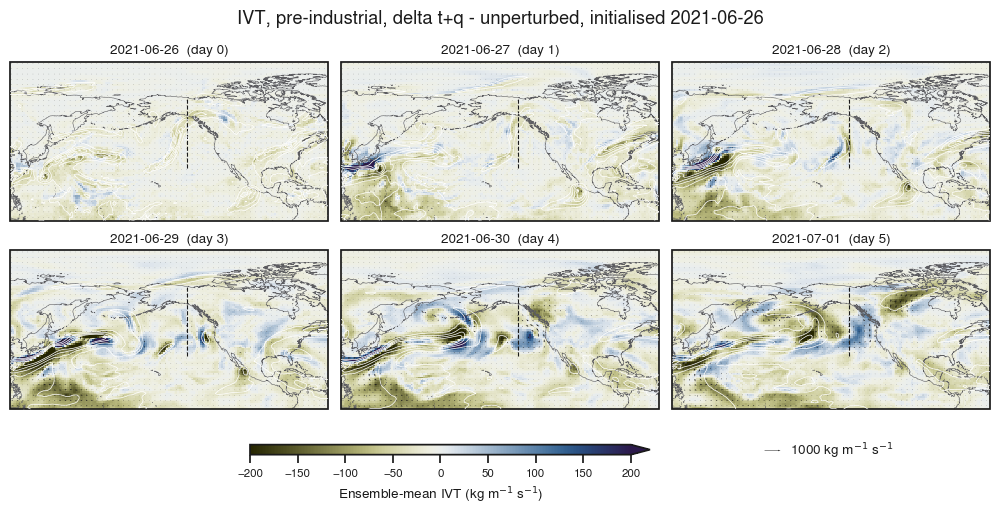

In [34]:
for inidate in ivt.inidate.values:
    ivt_daily_maps(ivt.sel(climate='pi'), inidate, 
                   unperturbed=ivt_unperturbed,
                   climate_label=LABEL['pi'], perturbation_label=PERT_LABEL['tq'])

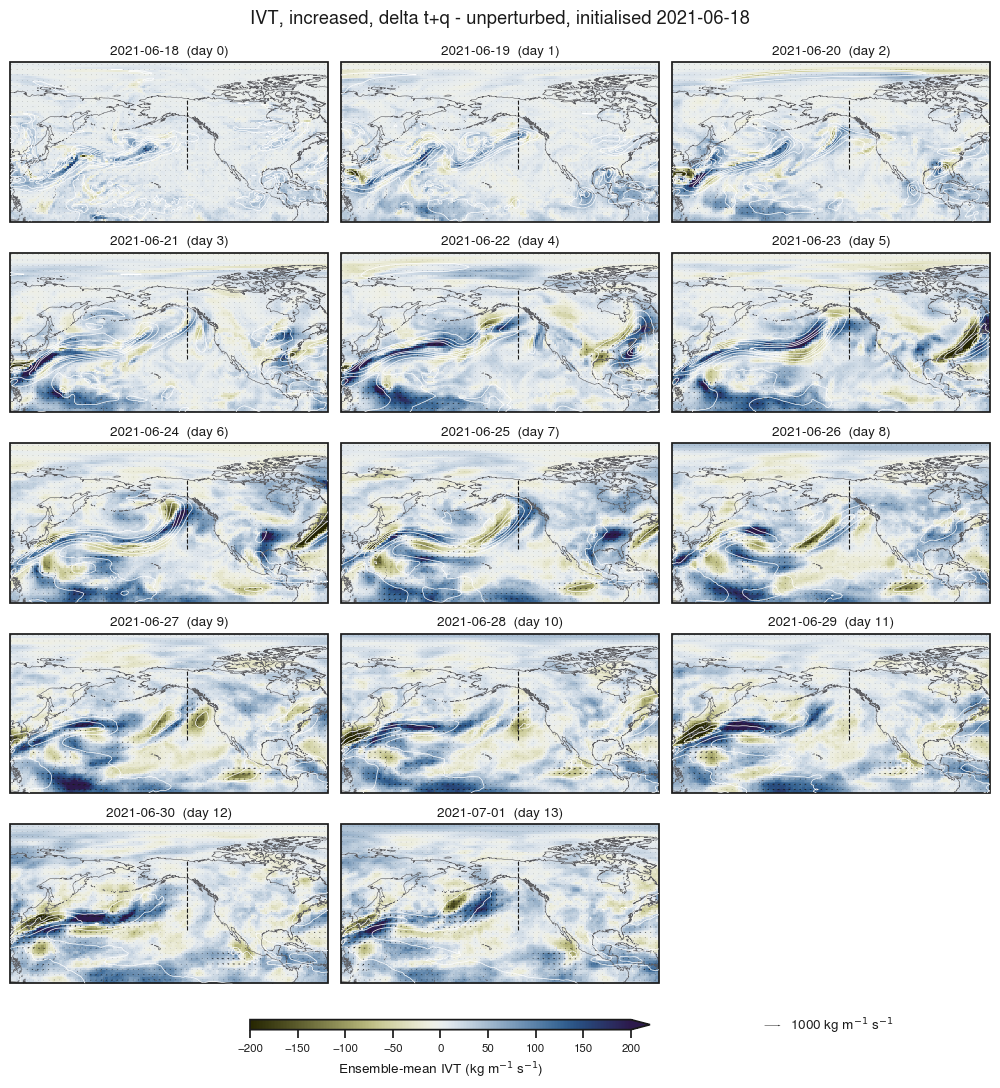

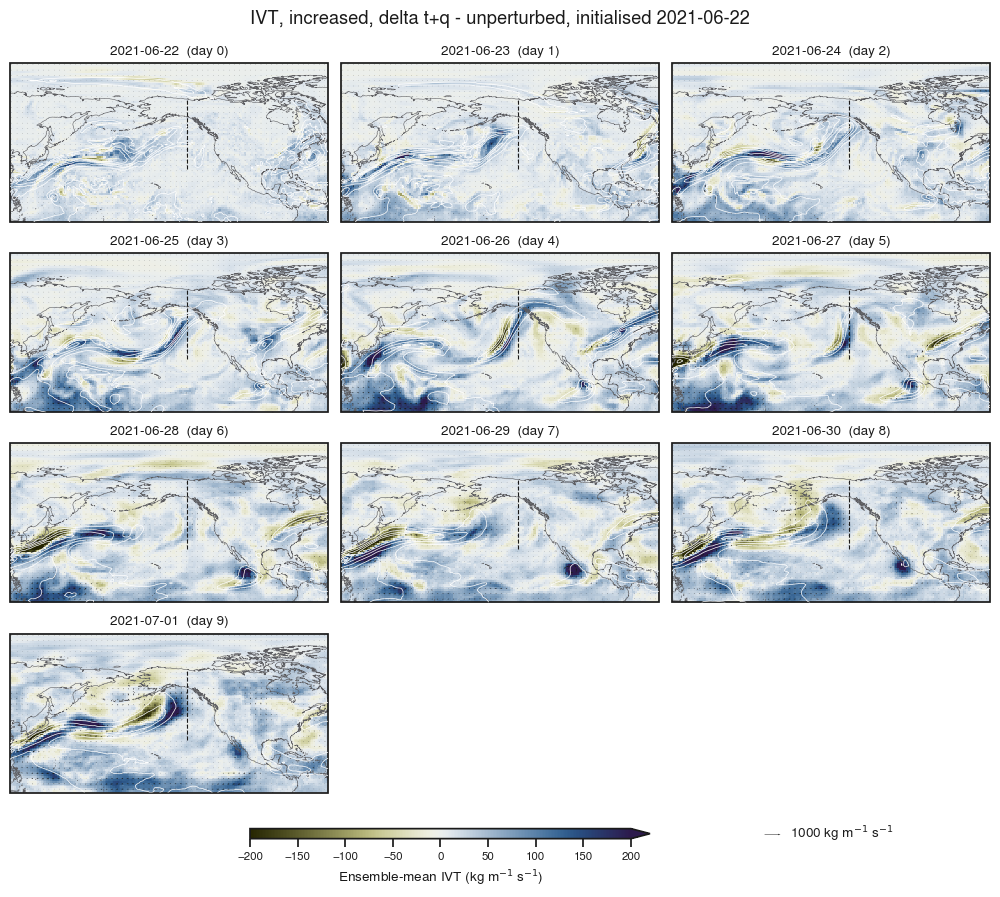

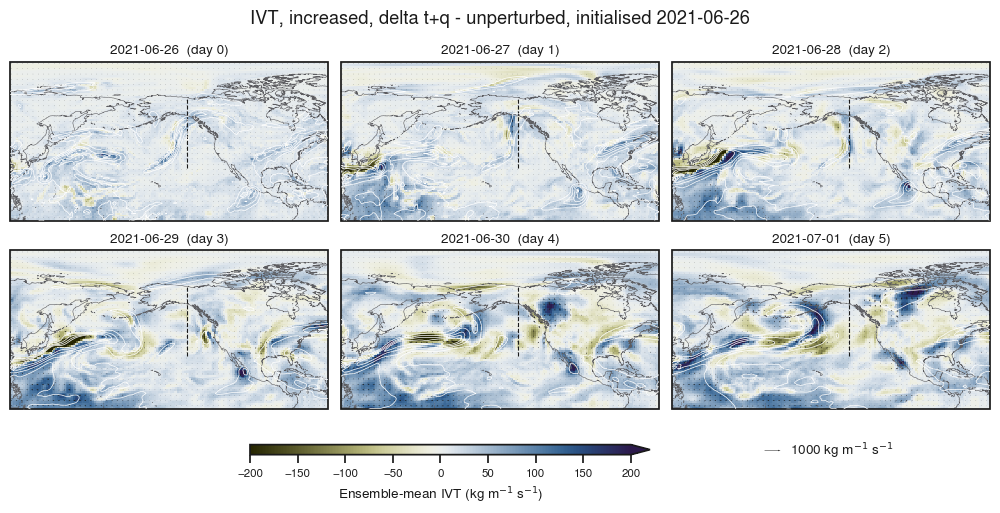

In [35]:
for inidate in ivt.inidate.values:
    ivt_daily_maps(ivt.sel(climate='incr'), inidate, 
                   unperturbed=ivt_unperturbed,
                   climate_label=LABEL['incr'], perturbation_label=PERT_LABEL['tq'])

In [28]:
# only the window the maps show is read: 0-90N, 120-300E
ivt_iterated = get_IVT(ifs_pl.sel(perturbation='iterated',
                         latitude=slice(90, 0), longitude=slice(120, 300)))
# magnitude per member first, then the ensemble mean
ivt_iterated['ivt'] = (ivt_iterated.q_u**2 + ivt_iterated.q_v**2)**(1/2)
ivt = ivt_iterated.mean('number').compute()

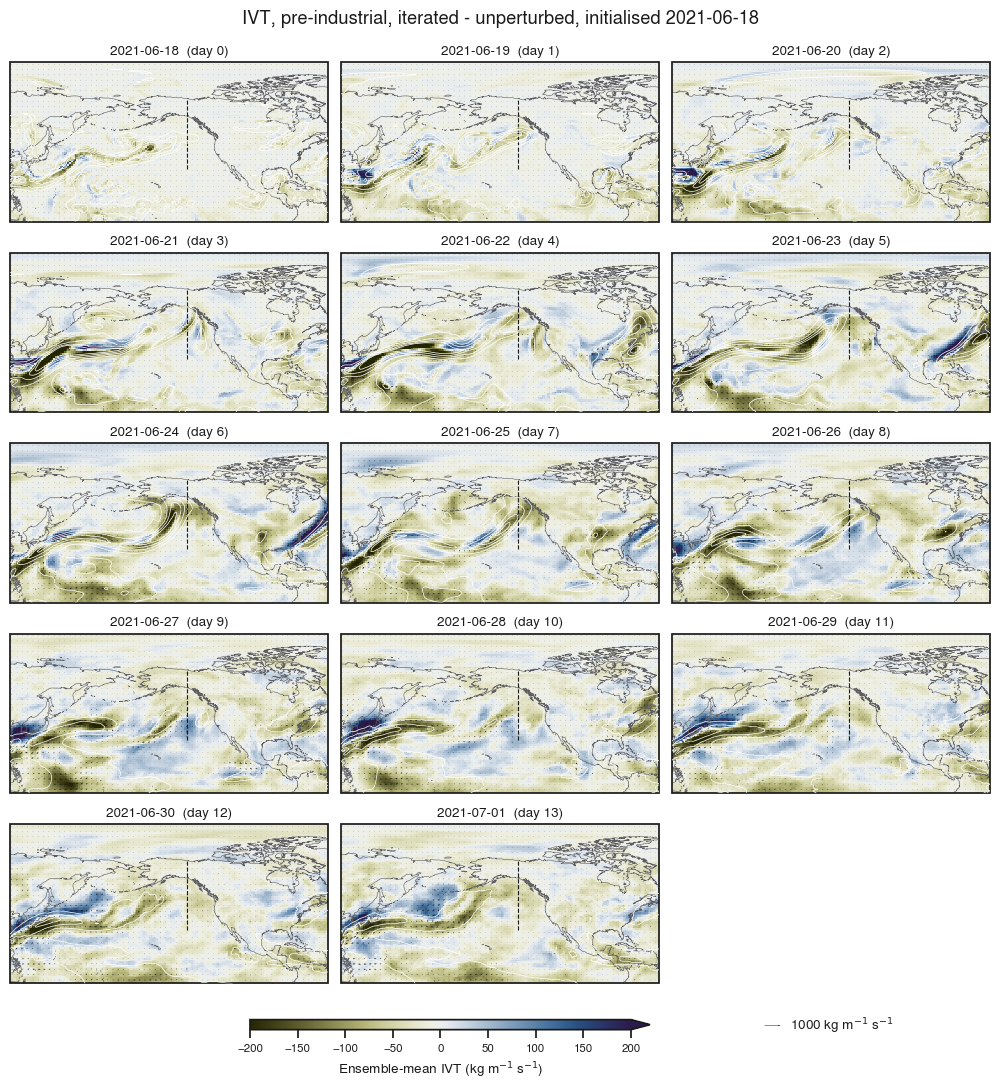

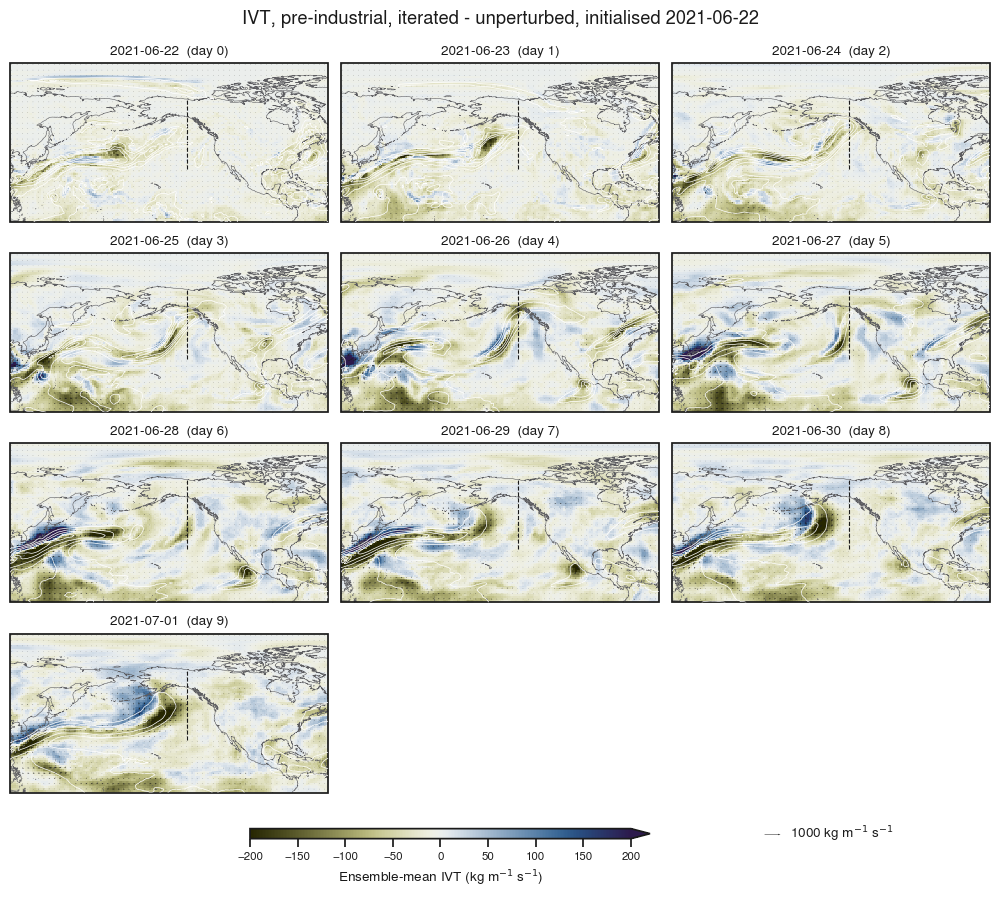

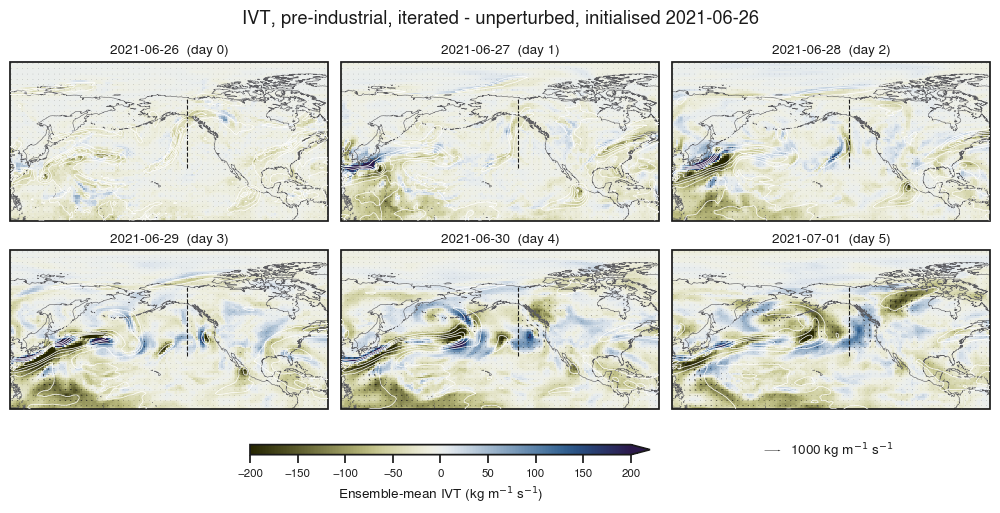

In [36]:
for inidate in ivt.inidate.values:
    ivt_daily_maps(ivt.sel(climate='pi'), inidate, 
                   unperturbed=ivt_unperturbed,
                   climate_label=LABEL['pi'], perturbation_label=PERT_LABEL['iterated'])

# Gradient in Z500

In [74]:
z500_grad = ifs_pl.sel(level=500, longitude=slice(180, 300), latitude=slice(70, 30)).z.isel(latitude=[0,-1]).diff('latitude').mean(dim=['longitude', 'number']).squeeze().compute()
z500_grad

<xarray.DataArray 'z' (climate: 3, perturbation: 5, time: 14, inidate: 3)> Size: 5kB
array([[[[3334.9942188 ,           nan,           nan],
         [3189.37806462,           nan,           nan],
         [2899.05925805,           nan,           nan],
         [3029.01073836,           nan,           nan],
         [3086.60253383, 3398.06588064,           nan],
         [3180.08905847, 3961.06234807,           nan],
         [3368.06662456, 4259.15062271,           nan],
         [3467.35526831, 4145.35722183,           nan],
         [3434.67392072, 3738.103647  , 3636.17845357],
         [3359.9050776 , 3550.37824709, 3189.30611036],
         [3187.071533  , 3642.56607456, 3163.48635509],
         [3076.17913144, 3667.02244216, 3394.39535354],
         [2987.3081207 , 3516.39004359, 3438.42627879],
         [2994.14063593, 3396.00749575, 3566.36623485]],

        [[3342.77714385,           nan,           nan],
         [3197.49677785,           nan,           nan],
         [2895.63586961,           nan,           nan],
         [3024.98504949,           nan,           nan],
         [3091.85007701, 3399.69817348,           nan],
...
         [3302.29740346, 3675.44618331, 3286.11821214],
         [3095.01195037, 3693.53424425, 3262.29362072],
         [3043.67662856, 3673.37814429, 3457.54155257],
         [2996.79403122, 3596.24820234, 3497.55819114],
         [2984.54293839, 3565.11503292, 3535.6056867 ]],

        [[3359.58794044,           nan,           nan],
         [3152.06895464,           nan,           nan],
         [2881.87281405,           nan,           nan],
         [3047.58918998,           nan,           nan],
         [3033.3997713 , 3436.17398109,           nan],
         [3282.31024514, 4020.20951932,           nan],
         [3389.90042359, 4328.27501341,           nan],
         [3378.80673096, 4214.49399827,           nan],
         [3194.40258282, 3620.91918579, 3683.34696167],
         [3094.37903404, 3428.9746012 , 3227.29635975],
         [3008.17025171, 3342.93875036, 3367.85623321],
         [3005.49980557, 3369.69315269, 3669.12528421],
         [3032.27145386, 3241.5568015 , 3398.11616711],
         [3062.34572616, 3168.03540882, 3478.96669672]]]])
Coordinates:
  * climate       (climate) object 24B 'pi' 'curr' 'incr'
  * perturbation  (perturbation) object 40B 'iterated' 'iterated_short' ... 'tq'
  * time          (time) datetime64[ns] 112B 2021-06-18 ... 2021-07-01
  * inidate       (inidate) datetime64[ns] 24B 2021-06-18 2021-06-22 2021-06-26
    latitude      float32 4B 30.0
    level         int32 4B 500
Attributes:
    units:          m**2 s**-2
    long_name:      Geopotential
    standard_name:  geopotential

In [75]:
z500_grad_df = z500_grad.to_dataframe().reset_index()

In [79]:
z500_grad_df

,climate,perturbation,time,inidate,latitude,level,z
0,pi,iterated,2021-06-18,2021-06-18,30.0,500,3334.994219
1,pi,iterated,2021-06-18,2021-06-22,30.0,500,NaN
2,pi,iterated,2021-06-18,2021-06-26,30.0,500,NaN
3,pi,iterated,2021-06-19,2021-06-18,30.0,500,3189.378065
4,pi,iterated,2021-06-19,2021-06-22,30.0,500,NaN
...,...,...,...,...,...,...,...
625,incr,tq,2021-06-30,2021-06-22,30.0,500,3241.556802
626,incr,tq,2021-06-30,2021-06-26,30.0,500,3398.116167
627,incr,tq,2021-07-01,2021-06-18,30.0,500,3062.345726
628,incr,tq,2021-07-01,2021-06-22,30.0,500,3168.035409


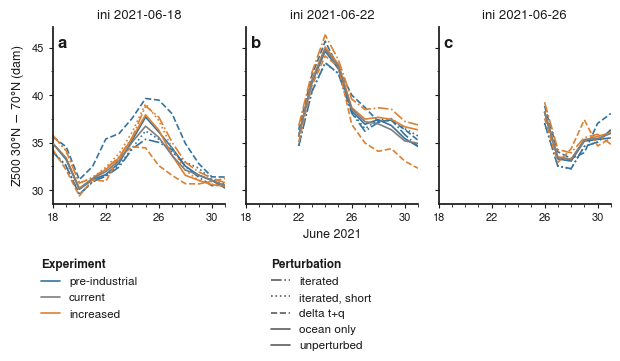

In [81]:
# which (climate, perturbation) combinations actually ran? the concat NaN-fills the rest
present = [(str(c), str(p))
           for c in z500_grad.climate.values for p in z500_grad.perturbation.values
           if bool(z500_grad.sel(climate=c, perturbation=p).notnull().any())]

ncol = len(z500_grad.inidate)

# drawn on the style.py reference canvas, so the sizes quoted there are the
# sizes the figure prints at; scaled() keeps that true if the canvas changes
fig = plt.figure(figsize=(atmicp.style.REF_WIDTH, 2.3))
gs = fig.add_gridspec(1, ncol, wspace=0.12)

axes = []
for i, inidate in enumerate(z500_grad.inidate.values):
    # shared axes: the same dates line up down the page and the gradients compare across lead times
    ax = fig.add_subplot(gs[0, i], sharex=axes[0] if axes else None, sharey=axes[0] if axes else None)
    axes.append(ax)

    for climate, pert in present:
        da = z500_grad.sel(inidate=inidate, climate=climate, perturbation=pert).dropna('time')
        if da.size == 0:
            continue
        # geopotential (m2 s-2) -> geopotential height (dam); the unperturbed run on
        # top, as the baseline the others move from
        ax.plot(da.time, da / 98.0665, color=CLIM[climate], linestyle=LS[pert], linewidth=1.2,
                zorder=3 if pert == 'none' else 2)

    ax.set_title(f'ini {np.datetime_as_string(inidate, unit="D")}',
                 fontsize=atmicp.style.scaled(atmicp.style.FS_TITLE, fig))
    ax.set_ylabel('Z500 30°N $-$ 70°N (dam)' if i == 0 else '',
                  fontsize=atmicp.style.scaled(atmicp.style.FS_LABEL, fig))
    # the shared style draws no tick marks; both axes carry them here
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
    ax.tick_params(which='major', bottom=True, left=True, length=3, width=0.8,
                   labelsize=atmicp.style.scaled(atmicp.style.FS_TICK, fig))
    ax.tick_params(which='minor', bottom=True, left=True, length=1.8, width=0.6)
    ax.tick_params(labelleft=i == 0)
    sns.despine(ax=ax)

# labelled every four days from the first inidate, so each inidate sits on a label;
# day of month only, as full dates run into the neighbouring panel
ticks = pd.date_range(z500_grad.time.values[0], z500_grad.time.values[-1], freq='4D')
for i, ax in enumerate(axes):
    ax.set_xlim(z500_grad.time.values[0], z500_grad.time.values[-1])
    ax.set_xticks(ticks)
    ax.set_xticks(z500_grad.time.values, minor=True)
    ax.set_xticklabels([f'{t:%-d}' for t in ticks])
    # one x label under the middle panel
    ax.set_xlabel('June 2021' if i == ncol // 2 else '',
                  fontsize=atmicp.style.scaled(atmicp.style.FS_LABEL, fig))

atmicp.style.panel_labels(axes)

# legend under the panels, one block per encoding
fs_legend = atmicp.style.scaled(atmicp.style.FS_ANNOT, fig)
heading = {'size': fs_legend, 'weight': 'bold'}


def entry(color, linestyle, label):
    return Line2D([0], [0], color=color, linestyle=linestyle, linewidth=1.2,
                  label=label)


blocks = [
    ('Experiment',
     [entry(CLIM[c], '-', LABEL[c])
      for c in ['pi', 'curr', 'incr'] if c in z500_grad.climate.values]),
    ('Perturbation',
     [entry(atmicp.style.MUTED, LS[p], PERT_LABEL[p])
      for p in PERT_LABEL if p in {p for _, p in present}]),
]

for x, (title, handles) in zip([0.10, 0.42], blocks):
    fig.legend(handles=handles, title=title, loc='upper left',
               bbox_to_anchor=(x, -0.10), bbox_transform=fig.transFigure,
               frameon=False, alignment='left', fontsize=fs_legend,
               title_fontproperties=heading, handlelength=1.6,
               labelspacing=0.5, borderpad=0.0)

atmicp.style.save(fig, '10_z500_gradient')
plt.show()